# DEA for downstream pseudobulk Enrichment Analysis

Activate kernel R/4.4.0

In [1]:
library(anndata)
library(dplyr)
library(DESeq2)
library(ggplot2)
library(ggpubr)
library('regionReport')
library(apeglm)
library("BiocParallel")


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, saveRDS, setdiff,
    table, tapply, union, unique, unsplit, which.max, which.min



Attachi

## **User Parameters**

In [2]:
# If working on Pseudobulk set pseudobulk <- TRUE ; if working at single cell level use pseudobulk <- FALSE
pseudobulk <- FALSE

**Pseudobulk Data Loading**

In [3]:
if (pseudobulk==TRUE) {
    ### Load filtered pseudobulk object - subset of muscles - created in Downstream_analysis_2 ###
    
    ## Params ##
    CELLS_PER_PSEUDOBULK = 30
    NGENES = 642 # Number of genes kept after filtering. Appears in name of h5ad file.
    
    
    # Goal: find the compromise between removing too much signal (left with too few genes) and having too many genes (increasing false positive rate)
    object <- paste0("pdata_muscle_D1_",NGENES,"Genes.h5ad")
    adata <- read_h5ad(paste0("./AnnData_Objects/Pseudobulks_",CELLS_PER_PSEUDOBULK,"cells/",object))
    print(adata)
}


**Single-cell Data Loading**

In [4]:
if (pseudobulk==FALSE) {
    object = read_h5ad("../AnnData_Objects/D1_embryo_head_with_anatomical_clusters.h5ad")
    adata <-  object[object$obs$anatomical_cluster != "None",]
    print(adata)
}
adata

View of AnnData object with n_obs × n_vars = 2195 × 18085
    obs: 'id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'clusters', 'expressing_MRFs', 'pitx2_expressed', 'tbx1_expressed', 'lmx1a_expressed', 'pax3_expressed', 'candidate_EOM', 'candidate_masseter', 'candidate_tongue', 'candidate_above_tongue', 'candidate_arches', 'anatomical_cluster'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'clusters', 'hvg', 'log1p', 'neighbors', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'counts', 'log_norm'
    obsp: 'connectivities', 'distances'


View of AnnData object with n_obs × n_vars = 2195 × 18085
    obs: 'id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'clusters', 'expressing_MRFs', 'pitx2_expressed', 'tbx1_expressed', 'lmx1a_expressed', 'pax3_expressed', 'candidate_EOM', 'candidate_masseter', 'candidate_tongue', 'candidate_above_tongue', 'candidate_arches', 'anatomical_cluster'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'clusters', 'hvg', 'log1p', 'neighbors', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'counts', 'log_norm'
    obsp: 'connectivities', 'distances'

## Prepare the data for DESeq2

Tuto: https://bioconductor.org/packages/devel/bioc/vignettes/DESeq2/inst/doc/DESeq2.html#countmat

**Important Note of DESeq2 regarding normalization: The DESeq2 model internally corrects for library size, so transformed or normalized values such as counts scaled by library size should not be used as input. DESeq2 will only work on INTEGERS anyway (if you normalized before, most likely the count matrix does not contain integers).**

In [5]:
cts <- t(as.matrix(adata$layers['counts']))
head(cts,2)

,ID_100245,ID_100441,ID_10053,ID_100574,ID_10063,ID_100652,ID_10078,ID_10080,ID_100874,ID_101092,⋯,ID_9823,ID_9829,ID_9842,ID_98497,ID_9867,ID_9891,ID_9909,ID_9931,ID_9956,ID_9967
SAMD11,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
NOC2L,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [6]:
# Sample Information Table (metadata)

coldata <- select(adata$obs, anatomical_cluster)
names(coldata)[names(coldata) == "anatomical_cluster"] <- "condition"
coldata$condition <- factor(coldata$condition)
head(coldata,2)

,condition
,<fct>
ID_100245,EOM
ID_100441,EOM


In [7]:
# Columns of the count matrix and the rows of coldata MUST be in same order

cts <- cts[, rownames(coldata)]
all(rownames(coldata) == colnames(cts))

[1] TRUE

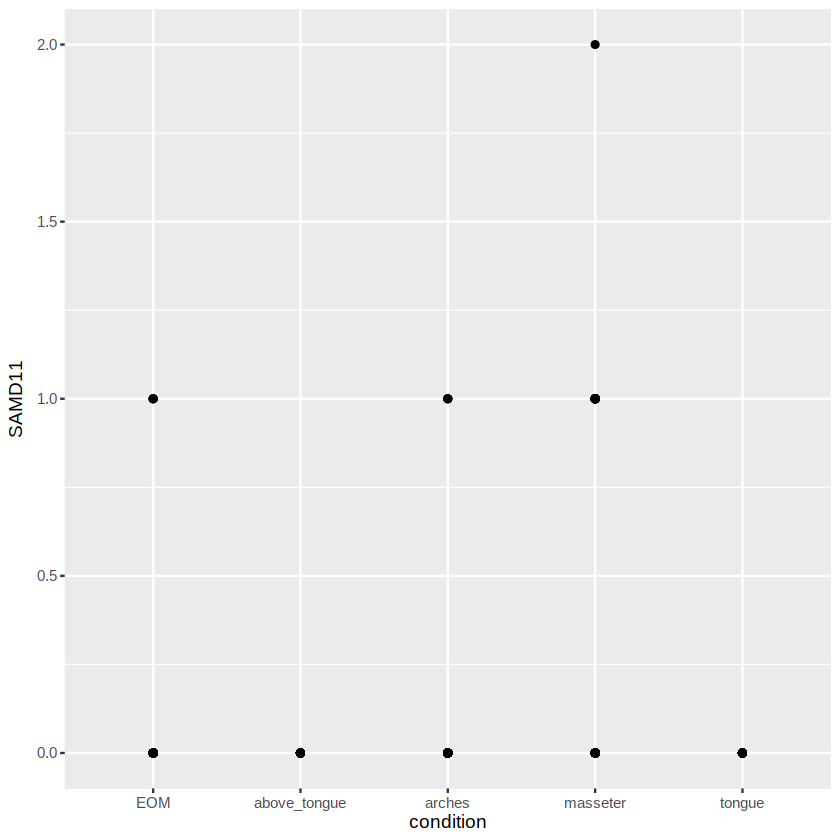

In [8]:
## Visualization for one gene ##

# Transform into long format
rowname <- rownames(cts)[1]       # Get the first row name ("foo")
first_row <- cts[1, ]             # Get the first row (as a 1-row data.frame)
result <- data.frame(
  name = names(first_row),
  value = as.numeric(first_row)
)
names(result)[2] <- rowname      # Rename second column
results <- as.data.frame(result)

# coldata prepare
df <- as.data.frame(coldata)
df$name <- rownames(coldata)

# merge
merged <- merge(result, df, by.x = "name", by.y = "name")

# Plot
ggplot(data=merged, aes(y=SAMD11, x=condition)) +
geom_point()

## Method1: for each gene, compare one cluster to the average of other clusters

Advantages: not a pairwise comparison

Drawbacks: averaging genes across very distinct clusters, potentially masking ("gomme") their signal. Or maybe not very meaningful as we average across very distinct clusters.

In [8]:
design_method1 <- ~ 0 + condition #0 force l'ordonnée à l'origine à zero, donc on compare la différence des moyennes à zero

# prepare DESeqDataSet, the input for DEA
dds <- DESeqDataSetFromMatrix(countData = cts,
                              colData = coldata,
                              design =  design_method1) 
dds

converting counts to integer mode



class: DESeqDataSet 
dim: 642 72 
metadata(1): version
assays(1): counts
rownames(642): AGRN CCNL2 ... MT-ND6 MT-CYB
rowData names(0):
colnames(72): 0_EOM 1_EOM ... 5_tongue 6_tongue
colData names(1): condition

In [9]:
levels(dds$condition)

[1] "EOM"          "above_tongue" "arches"       "masseter"     "tongue"

**Differential Expression Analysis**

In [8]:
# Wrapper of all steps: estimates dispersion, fits the model and tests for differential expression
dds <- DESeq(dds)

# Print the list of names of the coefficients in the model
#resultsNames(dds)

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



In [9]:
# Table of results One condition vs. Average of all other conditions
# REPLACE in contrast = list(c('One condition'),c(all other conditions))
# REPLACE in listValues by the weights to be given: c(1, -1/4) will do 1*(first condition) - 1/4*(condition2 + condition3 + condition4 + condition5)
res <- results(dds, 
               contrast =  list ( c('conditionmasseter'), c('conditionEOM','conditiontongue','conditionarches','conditionabove_tongue')) , listValues=c(1, -1/4))

# Filter for significant genes
res_filtered <- res[ which(res$padj < 0.05 & !is.na(res$padj)), ]
res_filtered

log2 fold change (MLE): conditionmasseter vs 0.25 conditionEOM+conditiontongue+conditionarches+conditionabove_tongue 
Wald test p-value: conditionmasseter vs 0.25 conditionEOM+conditiontongue+conditionarches+conditionabove_tongue 
DataFrame with 22 rows and 6 columns
           baseMean log2FoldChange     lfcSE      stat      pvalue        padj
          <numeric>      <numeric> <numeric> <numeric>   <numeric>   <numeric>
CNN3        6.47531      -0.336394 0.1132965  -2.96914 2.98630e-03 7.55357e-03
TNNI1       5.04848      -0.548839 0.1320539  -4.15618 3.23617e-05 1.39155e-04
COL3A1     20.44048       0.387703 0.0768443   5.04530 4.52809e-07 2.43385e-06
EGR1        5.33058      -0.314995 0.1256924  -2.50607 1.22080e-02 2.38611e-02
HNRNPA2B1   6.14168       0.313337 0.1159720   2.70183 6.89591e-03 1.48262e-02
...             ...            ...       ...       ...         ...         ...
MT-CO2      10.7679       0.218952 0.0867394   2.52426 0.011594373 0.023740860
MT-ATP6     17.2064  

## Method2: Pairwise comparisons

Advantage: most common method, fewer source of misunderstanding. More confident about the design formula.

Drawback: not really interested by signatures in one cluster compared to another cluster; but rather in one cluster compared to all other muscle clusters


**Might be the best if we add a step of selecting genes that appear significant in several pairwise comparisons (involving the same cluster of interest).
eg if geneA is reported as upregulated in EOM vs. masseter and in EOM vs. arches, it provides evidence that geneA is a signature of EOM.**

In [19]:
# Prepare data

design_method2 <- ~ 1 + condition #intercept of 1 to test for differences; if you force intercept to be 0 you'll be getting coefficients corresponding to the averages rather than differences

# Use parallelization if single cells to speed up AND DON'T FORGET TO SIMPLY FILTER OUT GENES to avoid sending useless jobs (many tests because many genes) to multiple cores
if (pseudobulk==FALSE) {
    register(MulticoreParam(4))
    parallel_=TRUE
}

dds <- DESeqDataSetFromMatrix(countData = cts,
                              colData = coldata,
                              design = design_method2 ) 
dds

converting counts to integer mode



class: DESeqDataSet 
dim: 18085 2195 
metadata(1): version
assays(1): counts
rownames(18085): SAMD11 NOC2L ... MT-ND6 MT-CYB
rowData names(0):
colnames(2195): ID_100245 ID_100441 ... ID_9956 ID_9967
colData names(1): condition

In [10]:
### FILTERING ###

# For single cells (if pseudobulk, it was done previously when generating pseudobulks)
# Keep genes with at least some counts in at least X cells. Recommendation is to use as X the size of the smallest group.

# 1. Get smallest group size
table(adata$obs$anatomical_cluster)

# but it's too big actually 


         EOM above_tongue       arches     masseter       tongue 
         386           95          363         1140          211 

In [20]:
dds_filtered <- dds
gene_sums <- rowSums(counts(dds_filtered))

# Keep genes with sum > 0 (i.e., non-zero in at least one sample)
keep <- gene_sums > 0

# Subset the DESeqDataSet
dds_filtered <- dds_filtered[keep, ]
dds_filtered

class: DESeqDataSet 
dim: 14640 2195 
metadata(1): version
assays(1): counts
rownames(14640): SAMD11 NOC2L ... MT-ND6 MT-CYB
rowData names(0):
colnames(2195): ID_100245 ID_100441 ... ID_9956 ID_9967
colData names(1): condition

In [21]:
# 2. Filtering
smallestGroupSize <- 10
if (pseudobulk==FALSE) {
    min_nb_cells <- smallestGroupSize
    min_counts <- 2
    keep <- rowSums(counts(dds) >= min_counts) >= min_nb_cells
    dds_filtered <- dds[keep,]
    }
dds_filtered

class: DESeqDataSet 
dim: 646 2195 
metadata(1): version
assays(1): counts
rownames(646): AGRN INTS11 ... MT-ND6 MT-CYB
rowData names(0):
colnames(2195): ID_100245 ID_100441 ... ID_9956 ID_9967
colData names(1): condition

In [22]:
dds <- dds_filtered

**Following DESeq2 vignette advices: check the PCA colored by our condition (anatomical cluster): if one group has bigger within-group variability, exclude it from the testing. Otherwise, perform all tests and then use contrasts in results to extract the interesting pairwise tests**

In [23]:
rld <- rlog(dds)
plotPCA(rld, intgroup="condition")

rlog() may take a long time with 50 or more samples,
vst() is a much faster transformation



ERROR: Error in estimateSizeFactorsForMatrix(counts(object), locfunc = locfunc, : every gene contains at least one zero, cannot compute log geometric means


### Method in case there is no big within-group variability

In [15]:
dds <- DESeq(dds, parallel=parallel_)
resultsNames(dds)

estimating size factors



ERROR: Error in estimateSizeFactorsForMatrix(counts(object), locfunc = locfunc, : every gene contains at least one zero, cannot compute log geometric means


- Intercept: corresponds to our reference level i.e. to EOM
- condition_above_tongue_vs_EOM: corresponds to the difference between 'above tongue' and reference level
- etc

**Results**

*Note:* A gene with LFC>0 is upregulated in the group 1 in "condition_group1_vs_group2" while LFC<0 means downregulated in group1 i.e. upregulated in group2 (=reference=EOM here) as it's pairwise comparison.

In [17]:
# Get results for comparisons of interest
padj_threshold <- 0.05

# Don't filter it to keep all "stat" values (t-statistic of Wald test, for TF enrichment in Downstream_Analysis_2.ipynb)
res <- results(dds, contrast = list("condition_above_tongue_vs_EOM"), alpha=padj_threshold) #alpha used for padj threshold in summary, but not filtering the results table

# Re-adjust logFC i.e. shrink, for plotting (as a check step)
resLFC <- lfcShrink(dds, coef="condition_above_tongue_vs_EOM", type="apeglm", parallel=parallel_)
res_above_tongue_vs_EOM_shrink <- as.data.frame(resLFC[ which(resLFC$padj < padj_threshold & !is.na(resLFC$padj)), ])

# Not only significant values
res_above_tongue_vs_EOM <- as.data.frame(res)

print("Above tongue versus. EOM:")
summary(res)

using 'apeglm' for LFC shrinkage. If used in published research, please cite:
    Zhu, A., Ibrahim, J.G., Love, M.I. (2018) Heavy-tailed prior distributions for
    sequence count data: removing the noise and preserving large differences.
    Bioinformatics. https://doi.org/10.1093/bioinformatics/bty895



[1] "Above tongue versus. EOM:"

out of 642 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 29, 4.5%
LFC < 0 (down)     : 1, 0.16%
outliers [1]       : 0, 0%
low counts [2]     : 0, 0%
(mean count < 1)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



In [18]:
res <- results(dds, contrast = list("condition_arches_vs_EOM"), alpha=padj_threshold)

# Re-adjust logFC i.e. shrink
resLFC <- lfcShrink(dds, coef="condition_arches_vs_EOM", type="apeglm", parallel=parallel_)
res_arches_vs_EOM_shrink <- as.data.frame(resLFC[ which(resLFC$padj < padj_threshold & !is.na(resLFC$padj)), ])

# Not only significant values
res_arches_vs_EOM <- as.data.frame(res)

print("Arches versus. EOM:")
summary(res)

using 'apeglm' for LFC shrinkage. If used in published research, please cite:
    Zhu, A., Ibrahim, J.G., Love, M.I. (2018) Heavy-tailed prior distributions for
    sequence count data: removing the noise and preserving large differences.
    Bioinformatics. https://doi.org/10.1093/bioinformatics/bty895



[1] "Arches versus. EOM:"

out of 642 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 69, 11%
LFC < 0 (down)     : 33, 5.1%
outliers [1]       : 0, 0%
low counts [2]     : 0, 0%
(mean count < 1)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



In [19]:
res <- results(dds, contrast = list("condition_masseter_vs_EOM"), alpha=padj_threshold)

# Re-adjust logFC i.e. shrink, just for plotting (check step)
resLFC <- lfcShrink(dds, coef="condition_masseter_vs_EOM", type="apeglm", parallel=parallel_)
res_masseter_vs_EOM_shrink <- as.data.frame(resLFC[ which(resLFC$padj < padj_threshold & !is.na(resLFC$padj)), ])

# not only significant values
res_masseter_vs_EOM <- as.data.frame(res)

print("Masseter versus. EOM:")
summary(res)

using 'apeglm' for LFC shrinkage. If used in published research, please cite:
    Zhu, A., Ibrahim, J.G., Love, M.I. (2018) Heavy-tailed prior distributions for
    sequence count data: removing the noise and preserving large differences.
    Bioinformatics. https://doi.org/10.1093/bioinformatics/bty895



[1] "Masseter versus. EOM:"

out of 642 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 82, 13%
LFC < 0 (down)     : 43, 6.7%
outliers [1]       : 0, 0%
low counts [2]     : 0, 0%
(mean count < 1)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



In [20]:
res <- results(dds, contrast = list("condition_tongue_vs_EOM"), alpha=padj_threshold)


# Re-adjust logFC i.e. shrink
resLFC <- lfcShrink(dds, coef="condition_tongue_vs_EOM", type="apeglm", parallel=parallel_)
res_tongue_vs_EOM_shrink <- as.data.frame(resLFC[ which(resLFC$padj < padj_threshold & !is.na(resLFC$padj)), ])

# not only significant values
res_tongue_vs_EOM <- as.data.frame(res)

print("Tongue versus. EOM:")
summary(res)

using 'apeglm' for LFC shrinkage. If used in published research, please cite:
    Zhu, A., Ibrahim, J.G., Love, M.I. (2018) Heavy-tailed prior distributions for
    sequence count data: removing the noise and preserving large differences.
    Bioinformatics. https://doi.org/10.1093/bioinformatics/bty895



[1] "Tongue versus. EOM:"

out of 642 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 76, 12%
LFC < 0 (down)     : 26, 4%
outliers [1]       : 0, 0%
low counts [2]     : 0, 0%
(mean count < 1)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



**Comparisons between groups that aren't the reference level**

In other words, comparisons not involving EOM.

Structure: res_group2_group3 <- results(dds, contrast = list("colour_group2_vs_group1", 
                                                 "colour_group3_vs_group1"))

This new contrast takes as reference group3 (=tests if there is an increase from group3 to group2), i.e. it's equivalent to testing null hypothesis: Coefficient of group2 - Coefficient of group3 = 0. Thus logFC > 0 means gene is upregulated in group2, and logFC < 0 means gene is upregulated in group3.

In [21]:
# logFC > 0 : gene upregulated in masseter
# logFC < 0 : gene upregulated in arches
res <- results(dds, contrast = list("condition_masseter_vs_EOM", "condition_arches_vs_EOM"), alpha=padj_threshold)

# not only significant values
res_masseter_vs_arches <- as.data.frame(res)

print("Masseter versus. Arches:")
summary(res)

[1] "Masseter versus. Arches:"

out of 642 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 50, 7.8%
LFC < 0 (down)     : 61, 9.5%
outliers [1]       : 0, 0%
low counts [2]     : 0, 0%
(mean count < 1)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



In [22]:
# logFC > 0 : gene upregulated in masseter
# logFC < 0 : gene upregulated in above tongue
res <- results(dds, contrast = list("condition_masseter_vs_EOM", "condition_above_tongue_vs_EOM"), alpha=padj_threshold)

# not only significant values
res_masseter_vs_above_tongue <- as.data.frame(res)

print("Masseter versus. Above Tongue:")
summary(res)

[1] "Masseter versus. Above Tongue:"

out of 642 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 4, 0.62%
LFC < 0 (down)     : 26, 4%
outliers [1]       : 0, 0%
low counts [2]     : 0, 0%
(mean count < 1)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



**RATHER RUN THIS:**

In [23]:
### SAME AS BEFORE BUT JUST ANOTHER WAY OF WRITING: MORE UNDERSTANDABLE ###
# tuto from https://github.com/tavareshugo/tutorial_DESeq2_contrasts/blob/main/DESeq2_contrasts.md

# define the model matrix
mod_mat <- model.matrix(design(dds), colData(dds))

# calculate coefficient vectors for each group
EOM <- colMeans(mod_mat[dds$condition == "EOM", ])
masseter <- colMeans(mod_mat[dds$condition == "masseter", ])
arches <- colMeans(mod_mat[dds$condition == "arches", ])
above_tongue <- colMeans(mod_mat[dds$condition == "above_tongue", ])
tongue <- colMeans(mod_mat[dds$condition == "tongue", ])

# Define any contrast we want

### Expanded model contrasts:
#'Intercept', 'conditionEOM', 'conditionabove_tongue', 'conditionarches', 'conditionmasseter', 'conditiontongue'
# when defining contrasts in lfcShrink, it must match this

# Genes upregulated in Masseter compared to EOM
res2_masseter_EOM <- results(dds, contrast = masseter - EOM, alpha=padj_threshold)
# shink logFC
resLFC <- lfcShrink(dds, contrast=c(0, -1, 0, 0, 1, 0), res=res2_masseter_EOM, type="normal", parallel=parallel_)
# filter significant values
res2_masseter_EOM_shrink <- as.data.frame(resLFC[ which(resLFC$padj < padj_threshold & !is.na(resLFC$padj)), ])


# Genes upregulated in Arches compared to EOM
res2_arches_EOM <- results(dds, contrast = arches - EOM, alpha=padj_threshold)
resLFC <- lfcShrink(dds, contrast=c(0, -1, 0, 1, 0, 0), res=res2_arches_EOM, type="normal", parallel=parallel_)
res2_arches_EOM_shrink <- as.data.frame(resLFC[ which(resLFC$padj < padj_threshold & !is.na(resLFC$padj)), ])

# Genes upregulated in Above Tongue compared to EOM
res2_above_tongue_EOM <- results(dds, contrast = above_tongue - EOM, alpha=padj_threshold)
resLFC <- lfcShrink(dds, contrast=c(0, -1, 1, 0, 0, 0), res=res2_above_tongue_EOM, type="normal", parallel=parallel_)
res2_above_tongue_EOM_shrink <- as.data.frame(resLFC[ which(resLFC$padj < padj_threshold & !is.na(resLFC$padj)), ])

# Genes upregulated in Tongue compared to EOM
res2_tongue_EOM <- results(dds, contrast = tongue - EOM, alpha=padj_threshold)
resLFC <- lfcShrink(dds, contrast=c(0, -1, 0, 0, 0, 1), res=res2_tongue_EOM, type="normal", parallel=parallel_)
res2_tongue_EOM_shrink <- as.data.frame(resLFC[ which(resLFC$padj < padj_threshold & !is.na(resLFC$padj)), ])

# Genes upregulated in Masseter compared to Arches
res2_masseter_arches <- results(dds, contrast = masseter - arches, alpha=padj_threshold)
resLFC <- lfcShrink(dds, contrast=c(0, 0, 0, -1, 1, 0), res=res2_masseter_arches, type="normal", parallel=parallel_)
res2_masseter_arches_shrink <- as.data.frame(resLFC[ which(resLFC$padj < padj_threshold & !is.na(resLFC$padj)), ])

# Genes upregulated in Masseter compared to Above Tongue
res2_masseter_above_tongue <- results(dds, contrast = masseter - above_tongue, alpha=padj_threshold)
resLFC <- lfcShrink(dds, contrast=c(0, 0,-1,0,1,0), res=res2_masseter_EOM, type="normal", parallel=parallel_)
res2_masseter_above_tongue_shrink <- as.data.frame(resLFC[ which(resLFC$padj < padj_threshold & !is.na(resLFC$padj)), ])

# Genes upregulated in Masseter compared to Tongue
res2_masseter_tongue <- results(dds, contrast = masseter - tongue, alpha=padj_threshold)
resLFC <- lfcShrink(dds, contrast=c(0, 0,0,0,1,-1), res=res2_masseter_tongue, type="normal", parallel=parallel_)
res2_masseter_tongue_shrink <- as.data.frame(resLFC[ which(resLFC$padj < padj_threshold & !is.na(resLFC$padj)), ])

# Genes upregulated in Arches compared to Tongue
res2_arches_tongue <- results(dds, contrast = arches - tongue, alpha=padj_threshold)
resLFC <- lfcShrink(dds, contrast=c(0, 0,0,1,0,-1), res=res2_arches_tongue, type="normal", parallel=parallel_)
res2_arches_tongue_shrink <- as.data.frame(resLFC[ which(resLFC$padj < padj_threshold & !is.na(resLFC$padj)), ])

# Genes upregulated in Arches compared to Above Tongue 
res2_arches_above_tongue <- results(dds, contrast = arches - above_tongue, alpha=padj_threshold)
resLFC <- lfcShrink(dds, contrast=c(0, 0,-1,1,0,0), res=res2_arches_above_tongue, type="normal", parallel=parallel_)
res2_arches_above_tongue_shrink <- as.data.frame(resLFC[ which(resLFC$padj < padj_threshold & !is.na(resLFC$padj)), ])

# Genes upregulated in Above Tongue compared to Tongue
res2_above_tongue_tongue <- results(dds, contrast = above_tongue - tongue, alpha=padj_threshold)
resLFC <- lfcShrink(dds, contrast=c(0, 0,1,0,0,-1), res=res2_above_tongue_tongue, type="normal", parallel=parallel_)
res2_above_tongue_tongue_shrink <- as.data.frame(resLFC[ which(resLFC$padj < padj_threshold & !is.na(resLFC$padj)), ])


using 'normal' for LFC shrinkage, the Normal prior from Love et al (2014).

Note that type='apeglm' and type='ashr' have shown to have less bias than type='normal'.
See ?lfcShrink for more details on shrinkage type, and the DESeq2 vignette.
Reference: https://doi.org/10.1093/bioinformatics/bty895

resultsNames from the expanded model matrix to be referenced by 'contrast':

'Intercept', 'conditionEOM', 'conditionabove_tongue', 'conditionarches', 'conditionmasseter', 'conditiontongue'

using 'normal' for LFC shrinkage, the Normal prior from Love et al (2014).

Note that type='apeglm' and type='ashr' have shown to have less bias than type='normal'.
See ?lfcShrink for more details on shrinkage type, and the DESeq2 vignette.
Reference: https://doi.org/10.1093/bioinformatics/bty895

resultsNames from the expanded model matrix to be referenced by 'contrast':

'Intercept', 'conditionEOM', 'conditionabove_tongue', 'conditionarches', 'conditionmasseter', 'conditiontongue'

using 'normal' for LFC

### Method in case of within-group variability

In [ ]:
# Need to subset dds, i.e. filter the group with high within-variability

dds$condition <- factor(dds$condition, levels = c("EOM","masseter")) #takes as reference the first argument
dds$condition <- droplevels(dds$condition)

# Remove NA values i.e. samples not in the conditions being tested
dds <- dds[,!is.na(dds$condition)]

levels(dds$condition)

In [9]:
# DEA 
dds <- DESeq(dds)

# check the coefficients estimated by DEseq
resultsNames(dds)

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



[1] "Intercept"                     "condition_above_tongue_vs_EOM"
[3] "condition_arches_vs_EOM"       "condition_masseter_vs_EOM"    
[5] "condition_tongue_vs_EOM"

In [ ]:
# Extract results
res <- results(dds)

# Filter for significant genes
res_filtered <- res[ which(res$padj < 0.05 & !is.na(res$padj)), ]
res_filtered

### Check results by plotting

When genes are noisy, the logFC aren't reliable. Imagine a gene has low counts in both conditions being compared, the logFC will be mistakenly high. We can use "shrinkage" which is a method that compares genes will low or high counts to re-adjust the logFC. It does not impact the p-values.

In [29]:
res2_masseter_above_tongue_shrink["VGLL2",] #to compare the ratio of expression on plot to this logFC

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
VGLL2,2.814552,2.494118,0.4773735,5.531722,3.171015e-08,6.713805e-07


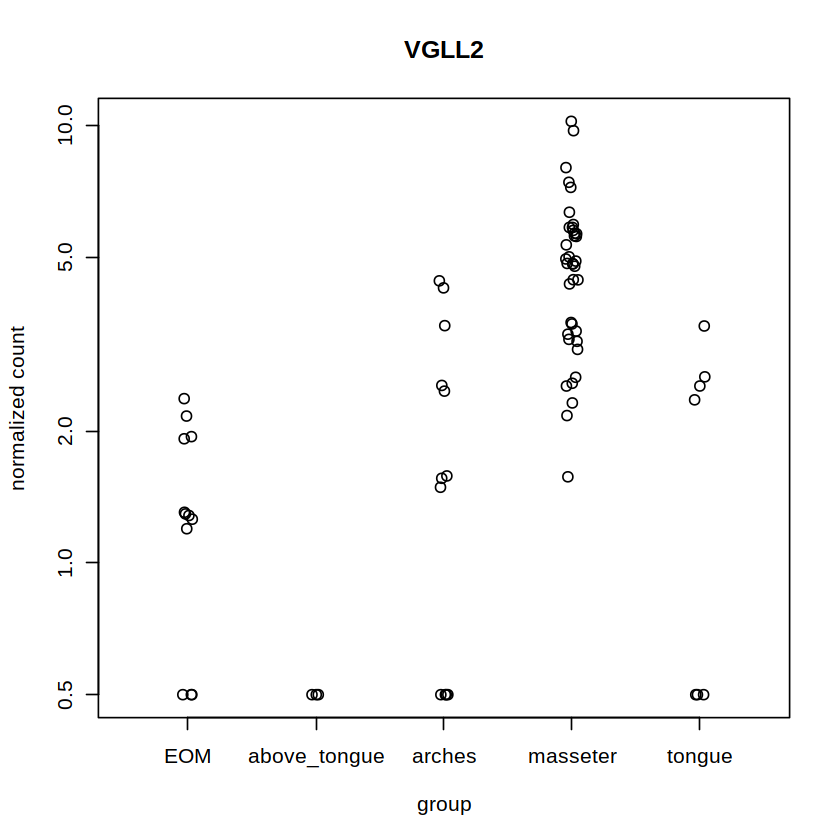

In [30]:
plotCounts(dds, gene="VGLL2", intgroup="condition") #gene=which.min(res_arches_vs_EOM$padj)

## Processing the results

Select genes upregulated in each category for at least 2 (half) comparisons.

In [24]:
comparisons_EOM <- c("masseter_EOM", "arches_EOM",  "above_tongue_EOM", "tongue_EOM") #upreg is logFC<0
comparisons_arches <- c("arches_EOM", "masseter_arches", "arches_tongue", "arches_above_tongue") 
comparisons_masseter <- c("masseter_arches", "masseter_above_tongue", "masseter_tongue", "masseter_EOM")
comparisons_above_tongue <- c("above_tongue_EOM","masseter_above_tongue", "arches_above_tongue", "above_tongue_tongue")
comparisons_tongue <- c("arches_tongue", "masseter_tongue", "above_tongue_tongue", "tongue_EOM")

res_EOM <- data.frame()
for (comparison in comparisons_EOM) {
    df <- get(paste0("res2_", comparison, "_shrink"))
    df$gene <- rownames(df)
    rownames(df) <- NULL
    res_EOM <- rbind(res_EOM,df) 
}
res_EOM <- res_EOM[which(res_EOM$log2FoldChange	< 0),]
# Select genes that appear upregulated in at least 2 comparisons
res_EOM |> dplyr::count(gene) |> filter(n>=2) |> select(gene) -> top_genes_EOM


res_arches <- data.frame()
for (comparison in comparisons_arches) {
    df <- get(paste0("res2_", comparison, "_shrink"))
    if (comparison=="masseter_arches"){
        df <- df[which(df$log2FoldChange< 0),]
    } else {
        df <- df[which(df$log2FoldChange> 0),]
    }
    df$gene <- rownames(df)
    rownames(df) <- NULL
    res_arches <- rbind(res_arches,df) 
}
res_arches |> dplyr::count(gene) |> filter(n>=2) |> select(gene) -> top_genes_arches

res_masseter <- data.frame()
for (comparison in comparisons_masseter) {
    df <- get(paste0("res2_", comparison, "_shrink"))
    df$gene <- rownames(df)
    rownames(df) <- NULL
    res_masseter <- rbind(res_masseter,df) 
}
res_masseter <- res_masseter[which(res_masseter$log2FoldChange	> 0),]
# Select genes that appear upregulated in at least 2 comparisons
res_masseter |> dplyr::count(gene) |> filter(n>=2) |> select(gene) -> top_genes_masseter

res_above_tongue <- data.frame()
for (comparison in comparisons_above_tongue) {
    df <- get(paste0("res2_", comparison, "_shrink"))
    if (comparison %in% c("masseter_above_tongue","arches_above_tongue")){
        df <- df[which(df$log2FoldChange< 0),]
    } else {
        df <- df[which(df$log2FoldChange> 0),]
    }
    df$gene <- rownames(df)
    rownames(df) <- NULL
    res_above_tongue <- rbind(res_above_tongue,df) 
}
res_above_tongue |> dplyr::count(gene) |> filter(n>=2) |> select(gene) -> top_genes_above_tongue


res_tongue <- data.frame()
for (comparison in comparisons_tongue) {
    df <- get(paste0("res2_", comparison, "_shrink"))
    if (comparison == "tongue_EOM"){
        df <- df[which(df$log2FoldChange > 0),]
    } else {
        df <- df[which(df$log2FoldChange < 0),]
    }
    df$gene <- rownames(df)
    rownames(df) <- NULL
    res_tongue <- rbind(res_tongue,df) 
}
res_tongue |> dplyr::count(gene) |> filter(n>=2) |> select(gene) -> top_genes_tongue


## Save results, which will be loaded and used in Downstream_Analysis_2.ipynb

In [25]:
path=paste0("/pasteur/helix/projects/fast_npz/Naomie/Shahragim_Project/visium_HD/spatial_EOM/segmentation/StarDist/Pseudobulk_Analysis/DEA_results/Pseudobulks_",CELLS_PER_PSEUDOBULK, "cells/",NGENES,"Genes/")

if (!dir.exists(path)) {
  dir.create(path)
  cat("Directory created.\n")
} else {
  cat("Directory already exists.\n")
}

# Non-filtered results
comparisons <- c("masseter_EOM", "arches_EOM",  "above_tongue_EOM", "tongue_EOM", "masseter_arches", "masseter_above_tongue", "masseter_tongue", "arches_tongue", "arches_above_tongue", "above_tongue_tongue")
length(comparisons) #should be equal to 10

for (comparison in comparisons) {
    result_dataframe <- get(paste0("res2_",comparison))
    write.table(result_dataframe, file=paste0(path,comparison,".tsv"), sep="\t", quote=FALSE, row.names=TRUE, col.names=NA)
}

Directory created.


[1] 10

# Non-filtered results (all t-values are needed for TF enrichment analysis in Downstream_Analysis_2.ipynb)
for (comparison in comparisons) {
    result_dataframe <- get(paste0("res2_", comparison))
    write.table(result_dataframe, file=paste0(path,comparison,".tsv"), sep="\t", quote=FALSE, row.names=TRUE, col.names=NA)
}

In [26]:
# Filtered results with shrink values (for direct Heatmap and Dotplot plotting)

for (comparison in comparisons) {
    result_dataframe <- get(paste0("res2_",comparison, "_shrink"))
    write.table(result_dataframe, file=paste0(path,comparison,"_shrink.tsv"), sep="\t", quote=FALSE, row.names=TRUE, col.names=NA)
}


In [27]:
# top markers 
write.table(top_genes_EOM,file=paste0(path,"EOM_top_markers.tsv"), sep="\t", quote=FALSE, row.names=TRUE, col.names=NA)
write.table(top_genes_arches,file=paste0(path,"arches_top_markers.tsv"), sep="\t", quote=FALSE, row.names=TRUE, col.names=NA)
write.table(top_genes_tongue,file=paste0(path,"tongue_top_markers.tsv"), sep="\t", quote=FALSE, row.names=TRUE, col.names=NA)
write.table(top_genes_above_tongue,file=paste0(path,"above_tongue_top_markers.tsv"), sep="\t", quote=FALSE, row.names=TRUE, col.names=NA)
write.table(top_genes_masseter,file=paste0(path,"masseter_top_markers.tsv"), sep="\t", quote=FALSE, row.names=TRUE, col.names=NA)